In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [9]:
import os
for root, dirs, files in os.walk(path):
    print(root, len(files))

/kaggle/input/cat-and-dog 0
/kaggle/input/cat-and-dog/test_set 0
/kaggle/input/cat-and-dog/test_set/test_set 0
/kaggle/input/cat-and-dog/test_set/test_set/dogs 1013
/kaggle/input/cat-and-dog/test_set/test_set/cats 1012
/kaggle/input/cat-and-dog/training_set 0
/kaggle/input/cat-and-dog/training_set/training_set 0
/kaggle/input/cat-and-dog/training_set/training_set/dogs 4006
/kaggle/input/cat-and-dog/training_set/training_set/cats 4001


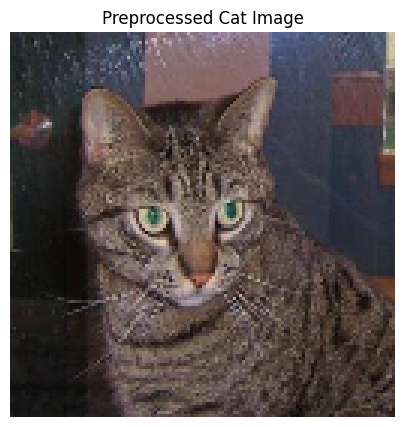

Image shape: (128, 128, 3)
Pixel range: 0.00392156862745098 to 0.8745098039215686


In [10]:
import cv2
import matplotlib.pyplot as plt

# Path to an image
image_path = "/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.1.jpg"

def preprocess_image(image_path, size=(128, 128)):
    # 1. Read image
    img = cv2.imread(image_path)

    # Check if image was loaded
    if img is None:
        raise ValueError("Could not read the image.")

    # 2. Resize to fixed size
    img = cv2.resize(img, size)

    # 3. Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 4. Normalize pixel values from [0, 255] to [0, 1]
    img = img / 255.0

    return img


# Apply preprocessing
img = preprocess_image(image_path)

# Visualize
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Preprocessed Cat Image")
plt.show()

# Check result
print("Image shape:", img.shape)
print("Pixel range:", img.min(), "to", img.max())

## OpenCV Image Preprocessing

A preprocessing function was created using OpenCV to standardize the input images before training.

The function performs four steps:

1. Reads the image using OpenCV.
2. Resizes the image to a fixed size of `128 × 128`.
3. Converts the image from BGR to RGB.
4. Normalizes pixel values from the range `0–255` to `0–1`.

This ensures that all images have a consistent size, color format, and pixel range before being used by the model.


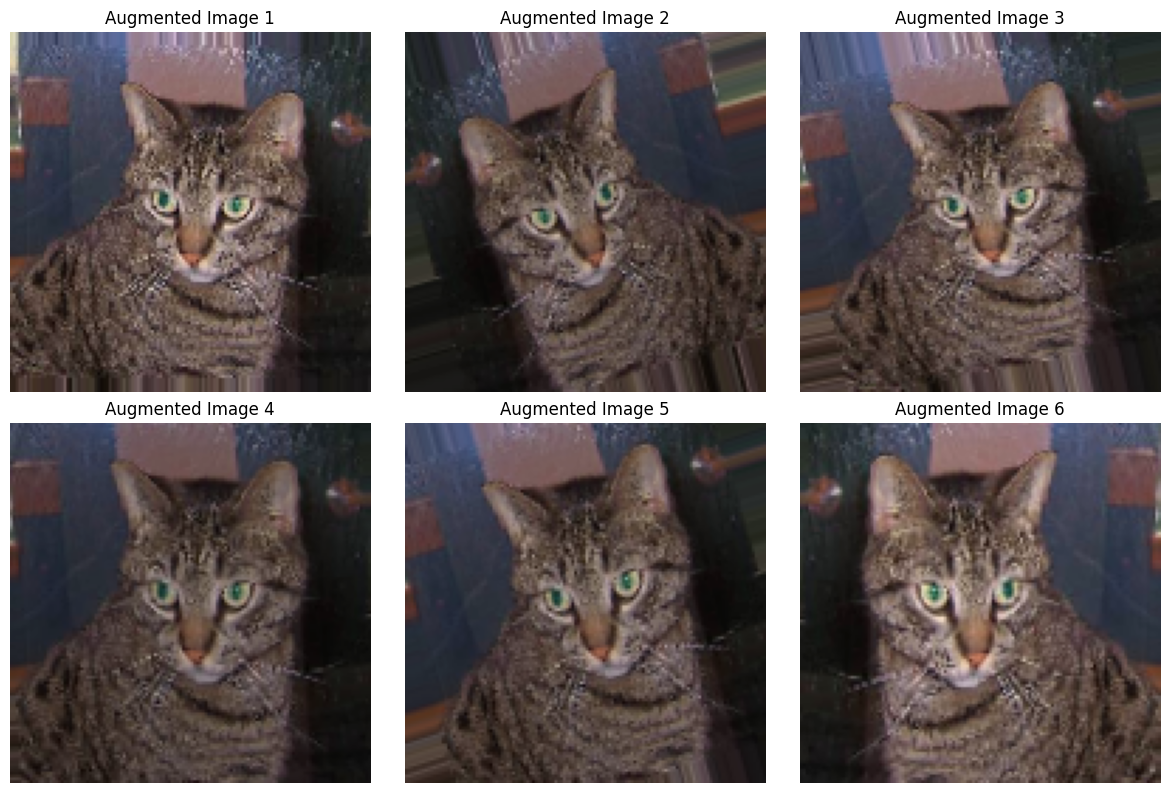

In [11]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np

# Path to one image
image_path = "/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.1.jpg"

# Load and resize image
image = load_img(image_path, target_size=(128, 128))

# Convert image to array
image_array = img_to_array(image)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# Create augmentation pipeline
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Generate augmented images
augmented_images = datagen.flow(
    image_array,
    batch_size=1
)

# Visualize augmented versions
plt.figure(figsize=(12, 8))

for i in range(6):
    augmented_image = next(augmented_images)[0].astype("uint8")

    plt.subplot(2, 3, i + 1)
    plt.imshow(augmented_image)
    plt.axis("off")
    plt.title(f"Augmented Image {i + 1}")

plt.tight_layout()
plt.show()

## Create an Augmentation Pipeline

Data augmentation is used to generate different variations of the same image. This helps increase data diversity and reduce overfitting by allowing the model to learn from different transformations of the original images.


In [12]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Load image
image_path = "/kaggle/input/cat-and-dog/training_set/training_set/cats/cat.1.jpg"

img = load_img(image_path, target_size=(224, 224))

# Convert image to array
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Apply MobileNetV2 preprocessing
preprocessed_img = preprocess_input(img_array)

print("Shape:", preprocessed_img.shape)
print("Min:", preprocessed_img.min())
print("Max:", preprocessed_img.max())

Shape: (1, 224, 224, 3)
Min: -1.0
Max: 0.94509804


## Pre-trained Model Preprocessing

For the image classification project, MobileNetV2 was selected as the pre-trained model.

The `preprocess_input` function provided by MobileNetV2 was applied to prepare the images according to the preprocessing method used during the model's original training.

This ensures that the input images have the expected format and pixel range before being passed to the pre-trained model.


In [13]:
!pip freeze > requirements.txt